# 1.  Setup


##1.1 Importing libraries

In [1]:
# Install any missing libraries
!pip install scikit-learn imbalanced-learn xgboost seaborn matplotlib pandas numpy -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import gc
import warnings
import glob
from collections import Counter
warnings.filterwarnings('ignore')

print("Libraries loaded successfully!")

Libraries loaded successfully!


##1.2 Mount drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


##1.3 Loading the data files

In [3]:
# Set the folder path
DATA_PATH = '/content/drive/MyDrive/CNS/data/'

csv_files = sorted(glob.glob(DATA_PATH + '*.csv'))
df_list = []
for file in csv_files:
    temp = pd.read_csv(file, low_memory=False)
    temp.columns = temp.columns.str.strip()
    df_list.append(temp)
    print(f"Loaded {file}")

del temp
gc.collect()

Loaded /content/drive/MyDrive/CNS/data/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Loaded /content/drive/MyDrive/CNS/data/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Loaded /content/drive/MyDrive/CNS/data/Friday-WorkingHours-Morning.pcap_ISCX.csv
Loaded /content/drive/MyDrive/CNS/data/Monday-WorkingHours.pcap_ISCX.csv
Loaded /content/drive/MyDrive/CNS/data/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Loaded /content/drive/MyDrive/CNS/data/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Loaded /content/drive/MyDrive/CNS/data/Tuesday-WorkingHours.pcap_ISCX.csv
Loaded /content/drive/MyDrive/CNS/data/Wednesday-workingHours.pcap_ISCX.csv


32

#2 EDA and Preprocessing


In [4]:
print(f"Columns of {os.path.basename(csv_files[0])}:")
print(df_list[0].columns)
print("=" * 65)

for i in range(1, len(df_list)):
    current_file_name = os.path.basename(csv_files[i])
    print(f"Comparing columns for {current_file_name}:")
    if df_list[0].columns.equals(df_list[i].columns):
        print("   Same columns as the first DataFrame.")
    else:
        print(f"   Columns are different:")
        print(df_list[i].columns)
    print("=" * 65)

Columns of Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv:
Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
       'Packet Length Std', 'P

- Notice that we see two column names that are almost the same (Fwd Header Length and Fwd Header Length.1) further investigation would be conducted on that
- we first check if they have the same values in order to safely drop one of them

In [5]:
for file in csv_files:
    name = os.path.basename(file)
    temp = pd.read_csv(file, low_memory=False)
    temp.columns = temp.columns.str.strip()

    if 'Fwd Header Length' in temp.columns and 'Fwd Header Length.1' in temp.columns:
        print(f" {name}")
        col1 = temp['Fwd Header Length']
        col2 = temp['Fwd Header Length.1']
        are_equal = col1.equals(col2)
        diff_count = (col1 != col2).sum()
        diff_pct = diff_count / len(temp) * 100
        print(f"   Are values identical     : {are_equal}")
        print(f"   Differing rows           : {diff_count:,}  ({diff_pct:.2f}%)")
        print(f"   Col1 mean                : {col1.mean():.4f}")
        print(f"   Col2 mean                : {col2.mean():.4f}")
        print(f"   Col1 min / max           : {col1.min()} / {col1.max()}")
        print(f"   Col2 min / max           : {col2.min()} / {col2.max()}")
        if diff_count > 0:
            print(f"\n   Sample of differing rows:")
            mask = col1 != col2
            print(temp.loc[mask, ['Fwd Header Length', 'Fwd Header Length.1']].head(10).to_string())
        print()
    else:
        print(f" {name}  ->  'Fwd Header Length.1' not found")
        print(f"   Columns containing 'Fwd Header' : {[c for c in temp.columns if 'Fwd Header' in c]}")
        print()

del temp
gc.collect()

 Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
   Are values identical     : True
   Differing rows           : 0  (0.00%)
   Col1 mean                : 111.5227
   Col2 mean                : 111.5227
   Col1 min / max           : 0 / 39396
   Col2 min / max           : 0 / 39396

 Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
   Are values identical     : True
   Differing rows           : 0  (0.00%)
   Col1 mean                : 91.8615
   Col2 mean                : 91.8615
   Col1 min / max           : 0 / 79632
   Col2 min / max           : 0 / 79632

 Friday-WorkingHours-Morning.pcap_ISCX.csv
   Are values identical     : True
   Differing rows           : 0  (0.00%)
   Col1 mean                : 324.4953
   Col2 mean                : 324.4953
   Col1 min / max           : 0 / 4369484
   Col2 min / max           : 0 / 4369484

 Monday-WorkingHours.pcap_ISCX.csv
   Are values identical     : True
   Differing rows           : 0  (0.00%)
   Col1 mean                : -1320

56

- The output shows that both columns have the same values so we will delete the one named "Fwd Header Length.1"

In [6]:
for i, temp in enumerate(df_list):
    if 'Fwd Header Length.1' in temp.columns:
        df_list[i] = temp.drop(columns=['Fwd Header Length.1'])
        print(f" Dropped from df_list[{i}]")
    else:
        print(f" Not found in df_list[{i}]")

 Dropped from df_list[0]
 Dropped from df_list[1]
 Dropped from df_list[2]
 Dropped from df_list[3]
 Dropped from df_list[4]
 Dropped from df_list[5]
 Dropped from df_list[6]
 Dropped from df_list[7]


In [7]:
for i in range(len(df_list)):
    print(os.path.basename(csv_files[i]))
    print(df_list[i].shape)
    print("=" * 65)

Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
(225745, 78)
Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
(286467, 78)
Friday-WorkingHours-Morning.pcap_ISCX.csv
(191033, 78)
Monday-WorkingHours.pcap_ISCX.csv
(529918, 78)
Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
(288602, 78)
Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
(170366, 78)
Tuesday-WorkingHours.pcap_ISCX.csv
(445909, 78)
Wednesday-workingHours.pcap_ISCX.csv
(692703, 78)


In [8]:
df_list[0].dtypes

,0
Destination Port,int64
Flow Duration,int64
Total Fwd Packets,int64
Total Backward Packets,int64
Total Length of Fwd Packets,int64
...,...
Idle Mean,float64
Idle Std,float64
Idle Max,int64
Idle Min,int64


In [9]:
df_list[0].head().transpose()

,0,1,2,3,4
Destination Port,54865,55054,55055,46236,54863
Flow Duration,3,109,52,34,3
Total Fwd Packets,2,1,1,1,2
Total Backward Packets,0,1,1,1,0
Total Length of Fwd Packets,12,6,6,6,12
...,...,...,...,...,...
Idle Mean,0.0,0.0,0.0,0.0,0.0
Idle Std,0.0,0.0,0.0,0.0,0.0
Idle Max,0,0,0,0,0
Idle Min,0,0,0,0,0


In [10]:
for i in range(len(df_list)):
    print(os.path.basename(csv_files[i]))
    print(df_list[i].describe())
    print("=" * 65)

Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
       Destination Port  Flow Duration  Total Fwd Packets  \
count      225745.00000   2.257450e+05      225745.000000   
mean         8879.61946   1.624165e+07           4.874916   
std         19754.64740   3.152437e+07          15.422874   
min             0.00000  -1.000000e+00           1.000000   
25%            80.00000   7.118000e+04           2.000000   
50%            80.00000   1.452333e+06           3.000000   
75%            80.00000   8.805237e+06           5.000000   
max         65532.00000   1.199999e+08        1932.000000   

       Total Backward Packets  Total Length of Fwd Packets  \
count           225745.000000                225745.000000   
mean                 4.572775                   939.463346   
std                 21.755356                  3249.403484   
min                  0.000000                     0.000000   
25%                  1.000000                    26.000000   
50%                  4.000000

In [11]:
file_summaries = []

for i, temp_df in enumerate(df_list):
    print("=" * 65)
    name = os.path.basename(csv_files[i])
    print(f" {name}")
    # temp = pd.read_csv(file, low_memory=False) # No need to reread
    # temp.columns = temp.columns.str.strip() # Already done during initial load
    n_rows, n_cols = temp_df.shape
    missing = temp_df.isnull().sum().sum()
    numeric = temp_df.select_dtypes(include=[np.number])
    inf_count = np.isinf(numeric).sum().sum()
    duplicates = temp_df.duplicated().sum()
    print(f"   Rows         : {n_rows:,}")
    print(f"   Columns      : {n_cols}")
    print(f"   Missing vals : {missing:,}")
    print(f"   Inf values   : {inf_count:,}")
    print(f"   Duplicates   : {duplicates:,}")
    print(f"   Labels found :")
    label_counts = temp_df['Label'].value_counts()
    for label, count in label_counts.items():
        pct = count / n_rows * 100
        print(f"      -> {label:<40} {count:>8,}  ({pct:.2f}%)")
    file_summaries.append({
        'file': name, 'rows': n_rows, 'missing': missing,
        'inf_values': inf_count, 'duplicates': duplicates,
        'n_labels': len(label_counts)
    })

print("\n" + "=" * 65)
print("SUMMARY TABLE")
print("=" * 65)
summary_df = pd.DataFrame(file_summaries)
print(summary_df.to_string(index=False))

# del temp # temp_df is local to loop, no need to delete explicitly
gc.collect()

 Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
   Rows         : 225,745
   Columns      : 78
   Missing vals : 4
   Inf values   : 64
   Duplicates   : 2,633
   Labels found :
      -> DDoS                                      128,027  (56.71%)
      -> BENIGN                                     97,718  (43.29%)
 Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
   Rows         : 286,467
   Columns      : 78
   Missing vals : 15
   Inf values   : 727
   Duplicates   : 72,353
   Labels found :
      -> PortScan                                  158,930  (55.48%)
      -> BENIGN                                    127,537  (44.52%)
 Friday-WorkingHours-Morning.pcap_ISCX.csv
   Rows         : 191,033
   Columns      : 78
   Missing vals : 28
   Inf values   : 216
   Duplicates   : 6,888
   Labels found :
      -> BENIGN                                    189,067  (98.97%)
      -> Bot                                         1,966  (1.03%)
 Monday-WorkingHours.pcap_ISCX.csv
   Rows   

0

- we notice that accross all the files there are duplicates and since they represent a small proportion of the data we can delete them after merging all the dataframes
- We can also notice that there are some label's encoding problem like "Web Attack � Sql Injection"
- We can see that there are infinite and missing values and we need to handle them(delete? impute?)
- The class imbalance is the most critical problem that we need to deal with appropriate sampling techniques
- The following section will handle all of these

###1. merging the dataframes


In [12]:
df = pd.concat(df_list, ignore_index=True)
print(f"Shape after merge : {df.shape}")

Shape after merge : (2830743, 78)


- freeing the RAM

In [13]:
del df_list
gc.collect()
print(f'RAM freed!')
print(f'df shape: {df.shape}')

RAM freed!
df shape: (2830743, 78)


###2. Dropping the duplicates

In [14]:
before = len(df)
df = df.drop_duplicates()
print(f"Shape after drop_duplicates: {df.shape}")
print(f"Dropped                    : {before - len(df):,} rows")

Shape after drop_duplicates: (2522362, 78)
Dropped                    : 308,381 rows


###3. Fixing the label ecoding

In [15]:
df['Label'] = (df['Label']
               .str.replace('Web Attack \ufffd Brute Force', 'Web Attack - Brute Force', regex=False)
               .str.replace('Web Attack \ufffd XSS', 'Web Attack - XSS', regex=False)
               .str.replace('Web Attack \ufffd Sql Injection', 'Web Attack - Sql Injection', regex=False)
               .str.strip())

In [16]:
df['Label'].value_counts()

,count
Label,
BENIGN,2096484
DoS Hulk,172849
DDoS,128016
PortScan,90819
DoS GoldenEye,10286
FTP-Patator,5933
DoS slowloris,5385
DoS Slowhttptest,5228
SSH-Patator,3219


###4. Handling infinite values




In [17]:
# Find columns that have Inf values
numeric_cols = df.select_dtypes(include=[np.number]).columns
inf_mask = np.isinf(df[numeric_cols])
inf_summary = inf_mask.sum()
inf_summary = inf_summary[inf_summary > 0].sort_values(ascending=False)

print("=== Columns Containing Inf Values ===\n")
for col, count in inf_summary.items():
    pct = count / len(df) * 100
    print(f"  {col:<35} {count:>8,}  ({pct:.4f}%)")

print(f"\nTotal inf values : {inf_mask.sum().sum():,}")
print(f"Affected columns : {len(inf_summary)}")

=== Columns Containing Inf Values ===

  Flow Packets/s                         1,564  (0.0620%)
  Flow Bytes/s                           1,211  (0.0480%)

Total inf values : 2,775
Affected columns : 2


- This is probably due to a division by zero since both columns are related to time (Flow Duration)
- In the following cell we'll check that

In [18]:
for col in inf_summary.index:
    inf_rows = df[np.isinf(df[col])]
    print(f"--- {col} ---")
    print(f"  Count          : {len(inf_rows):,}")
    print(f"  Label distribution in inf rows:")
    for label, count in inf_rows['Label'].value_counts().items():
        print(f"    -> {label:<40} {count:>6,}")
    print(f"  Flow Duration stats for these rows:")
    if 'Flow Duration' in df.columns:
        print(f"    min : {inf_rows['Flow Duration'].min()}")
        print(f"    max : {inf_rows['Flow Duration'].max()}")
        print(f"    mean: {inf_rows['Flow Duration'].mean():.4f}")
    print()

--- Flow Packets/s ---
  Count          : 1,564
  Label distribution in inf rows:
    -> BENIGN                                    1,427
    -> PortScan                                    125
    -> Bot                                           5
    -> DoS Hulk                                      3
    -> DDoS                                          2
    -> FTP-Patator                                   2
  Flow Duration stats for these rows:
    min : 0
    max : 0
    mean: 0.0000

--- Flow Bytes/s ---
  Count          : 1,211
  Label distribution in inf rows:
    -> BENIGN                                    1,077
    -> PortScan                                    125
    -> Bot                                           5
    -> DDoS                                          2
    -> FTP-Patator                                   2
  Flow Duration stats for these rows:
    min : 0
    max : 0
    mean: 0.0000



- The results show that the inf values are directly caused by the Flow Duration that is 0 and probably are incomplete flow records and the best solution is to drop them since they don't concern only one class and they represent 2,775 rows out of ~2.5M  ->  0.11% of dataset

- Deleting the rows

In [19]:
# Drop rows where Flow Duration = 0 (root cause of all Inf values)
before = len(df)
df = df[df['Flow Duration'] != 0]
after = len(df)

print(f"Rows before : {before:,}")
print(f"Rows after  : {after:,}")
print(f"Dropped     : {before - after:,} rows  ({(before-after)/before*100:.4f}%)")

# Verify no Inf values remain
numeric_cols = df.select_dtypes(include=[np.number]).columns
remaining_inf = np.isinf(df[numeric_cols]).sum().sum()
print(f"\n Remaining Inf values : {remaining_inf}")

Rows before : 2,522,362
Rows after  : 2,520,798
Dropped     : 1,564 rows  (0.0620%)

 Remaining Inf values : 0


###5. Handling missing values

In [20]:
missing_summary = df.isnull().sum()
missing_summary = missing_summary[missing_summary > 0].sort_values(ascending=False)

print("=== Columns Containing Missing Values ===\n")
if len(missing_summary) == 0:
    print("  No missing values found.")
else:
    for col, count in missing_summary.items():
        pct = count / len(df) * 100
        print(f"  {col:<35} {count:>8,}  ({pct:.4f}%)")

print(f"\nTotal missing values : {df.isnull().sum().sum():,}")
print(f"Affected columns     : {len(missing_summary)}")

=== Columns Containing Missing Values ===

  No missing values found.

Total missing values : 0
Affected columns     : 0


- The missing values are gone after we deleted the duplicates and the infinite values

- checking for features distribution

###6. Investigating negative values
- Two types were found:
  - **Case A : Integer overflow (drop):** `Flow Duration`, `Flow Bytes/s`, `Flow Packets/s`, `Fwd/Bwd Header Length`, `min_seg_size_forward` contain extreme negative values caused by CICFlowMeter integer overflow. All belong to BENIGN rows only.
  - **Case B : Sentinel -1 (replace with 0):** `Init_Win_bytes_forward` and `Init_Win_bytes_backward` use -1 to indicate no TCP window was observed.We cant drop those rows since they are meaningfull so we replace -1 with 0 to indicte the flow of 0 window size

  (check the explanation file for more details)
  **https://drive.google.com/drive/folders/1xuVOLpS6A619I4YHpz4RdsL16ydHnX0T?usp=sharing**

In [21]:
print("=== Negative Value Investigation ===\n")

should_be_positive = [
    'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
    'Total Length of Fwd Packets', 'Total Length of Bwd Packets',
    'Fwd Packet Length Max', 'Fwd Packet Length Min',
    'Fwd Packet Length Mean', 'Fwd Packet Length Std',
    'Bwd Packet Length Max', 'Bwd Packet Length Min',
    'Bwd Packet Length Mean', 'Bwd Packet Length Std',
    'Flow Bytes/s', 'Flow Packets/s',
    'Fwd Packets/s', 'Bwd Packets/s',
    'Min Packet Length', 'Max Packet Length',
    'Packet Length Mean', 'Packet Length Std',
    'Fwd Header Length', 'Bwd Header Length',
    'min_seg_size_forward', 'Average Packet Size',
    'Init_Win_bytes_forward', 'Init_Win_bytes_backward'
]

found_any = False
for col in should_be_positive:
    if col in df.columns:
        neg_count = (df[col] < 0).sum()
        if neg_count > 0:
            found_any = True
            neg_rows = df[df[col] < 0]
            print(f"--- {col} ---")
            print(f"  Negative rows   : {neg_count:,}")
            print(f"  Min value       : {df[col].min():,}")
            print(f"  Unique negatives: {sorted(neg_rows[col].unique())[:10]}")
            print(f"  Label distribution:")
            for label, count in neg_rows['Label'].value_counts().items():
                print(f"    -> {label:<40} {count:>6,}")
            print()

if not found_any:
    print("No unexpected negative values found!")

=== Negative Value Investigation ===

--- Flow Duration ---
  Negative rows   : 107
  Min value       : -13
  Unique negatives: [np.int64(-13), np.int64(-12), np.int64(-4), np.int64(-2), np.int64(-1)]
  Label distribution:
    -> BENIGN                                      107

--- Flow Bytes/s ---
  Negative rows   : 78
  Min value       : -261,000,000.0
  Unique negatives: [np.float64(-261000000.0), np.float64(-193000000.0), np.float64(-12000000.0), np.float64(-8000000.0), np.float64(-6000000.0), np.float64(-4000000.0), np.float64(-1000000.0), np.float64(-666666.6667), np.float64(-461538.4615)]
  Label distribution:
    -> BENIGN                                       78

--- Flow Packets/s ---
  Negative rows   : 107
  Min value       : -2,000,000.0
  Unique negatives: [np.float64(-2000000.0), np.float64(-1000000.0), np.float64(-500000.0), np.float64(-166666.6667), np.float64(-153846.1538)]
  Label distribution:
    -> BENIGN                                      107

--- Fwd Header L

###7. Fixing negative values

In [22]:
print("=== Fixing Negative Values ===\n")

# Case A: Drop rows with integer overflow corrupt values
overflow_cols = [
    'Flow Duration', 'Flow Packets/s',
    'Fwd Header Length', 'Bwd Header Length',
    'min_seg_size_forward'
]

before = len(df)
for col in overflow_cols:
    if col in df.columns:
        n = (df[col] < 0).sum()
        if n > 0:
            df = df[df[col] >= 0]
            print(f"  Dropped {n:,} rows with negative '{col}'")

# Flow Bytes/s: drop all negative values
n = (df['Flow Bytes/s'] < 0).sum()
if n > 0:
    df = df[df['Flow Bytes/s'] >= 0]
    print(f"  Dropped {n:,} rows with negative 'Flow Bytes/s'")

after = len(df)
print(f"\n  Total rows dropped : {before - after:,}")
print(f"  Remaining rows     : {after:,}")

# Case B: Replace -1 sentinel in Init_Win columns with 0
print()
for col in ['Init_Win_bytes_forward', 'Init_Win_bytes_backward']:
    n = (df[col] == -1).sum()
    df[col] = df[col].replace(-1, 0)
    print(f"  Replaced {n:,}  -1 values in '{col}' with 0")

# Verification
print("\n=== Verification ===")
all_clean = True
for col in overflow_cols + ['Flow Bytes/s', 'Init_Win_bytes_forward', 'Init_Win_bytes_backward']:
    if col in df.columns:
        n = (df[col] < 0).sum()
        status = 'clean' if n == 0 else f'{n:,} remaining!'
        print(f"  {col:<40} : {status}")
        if n > 0:
            all_clean = False

print(f"\n{'All columns clean' if all_clean else 'WARNING: Some negatives remain'}")

=== Fixing Negative Values ===

  Dropped 107 rows with negative 'Flow Duration'
  Dropped 35 rows with negative 'Fwd Header Length'

  Total rows dropped : 142
  Remaining rows     : 2,520,656

  Replaced 910,977  -1 values in 'Init_Win_bytes_forward' with 0
  Replaced 1,215,590  -1 values in 'Init_Win_bytes_backward' with 0

=== Verification ===
  Flow Duration                            : clean
  Flow Packets/s                           : clean
  Fwd Header Length                        : clean
  Bwd Header Length                        : clean
  min_seg_size_forward                     : clean
  Flow Bytes/s                             : clean
  Init_Win_bytes_forward                   : clean
  Init_Win_bytes_backward                  : clean

All columns clean


###8. Dropping zero-variance features
- Features with std=0 are entirely constant across the dataset and carry no information for any model so we can drop them safely

In [23]:
numeric_cols = df.select_dtypes(include=[np.number]).columns

# Identify features with zero variance
zero_var_cols = [col for col in numeric_cols if df[col].std() == 0]

print(f"Zero-variance features found: {len(zero_var_cols)}")
for col in zero_var_cols:
    print(f"  - {col}  (unique value: {df[col].unique()[0]})")

df = df.drop(columns=zero_var_cols)
print(f"\nDropped {len(zero_var_cols)} zero-variance features")
print(f"Remaining shape: {df.shape}")

Zero-variance features found: 8
  - Bwd PSH Flags  (unique value: 0)
  - Bwd URG Flags  (unique value: 0)
  - Fwd Avg Bytes/Bulk  (unique value: 0)
  - Fwd Avg Packets/Bulk  (unique value: 0)
  - Fwd Avg Bulk Rate  (unique value: 0)
  - Bwd Avg Bytes/Bulk  (unique value: 0)
  - Bwd Avg Packets/Bulk  (unique value: 0)
  - Bwd Avg Bulk Rate  (unique value: 0)

Dropped 8 zero-variance features
Remaining shape: (2520656, 70)


###9. Skewness Analysis
- Performed on the full cleaned dataset before splitting
- Features with skewness > 1 and min >= 0 are candidates for log1p transformation


In [24]:
numeric_cols = df.select_dtypes(include=[np.number]).columns

skew_df = pd.DataFrame({
    'mean'    : df[numeric_cols].mean(),
    'std'     : df[numeric_cols].std(),
    'min'     : df[numeric_cols].min(),
    'max'     : df[numeric_cols].max(),
    'skewness': df[numeric_cols].skew()
}).sort_values('skewness', ascending=False)

print('=== Top 20 Most Skewed Features (right skew) ===\n')
print(skew_df.head(20).to_string())

print('\n=== Bottom 10 Features (left skew / near zero) ===\n')
print(skew_df.tail(10).to_string())

print(f'\n=== Skewness Summary ===')
print(f'Highly right-skewed  (skew >  1) : {(skew_df["skewness"] >  1).sum()} features')
print(f'Highly left-skewed   (skew < -1) : {(skew_df["skewness"] < -1).sum()} features')
print(f'Approximately normal (-1 to 1)   : {((skew_df["skewness"] >= -1) & (skew_df["skewness"] <= 1)).sum()} features')

=== Top 20 Most Skewed Features (right skew) ===

                                     mean           std   min           max    skewness
Total Length of Fwd Packets  6.119302e+02  1.058851e+04   0.0  1.290000e+07  760.571213
Subflow Fwd Bytes            6.119185e+02  1.057418e+04   0.0  1.287034e+07  758.710473
act_data_pkt_fwd             6.009251e+00  6.744340e+02   0.0  2.135570e+05  268.556112
Total Backward Packets       1.157335e+01  1.056952e+03   0.0  2.919220e+05  230.890123
Subflow Bwd Packets          1.157335e+01  1.056952e+03   0.0  2.919220e+05  230.890123
Total Fwd Packets            1.028170e+01  7.944424e+02   1.0  2.197590e+05  230.608355
Subflow Fwd Packets          1.028170e+01  7.944424e+02   1.0  2.197590e+05  230.608355
Subflow Bwd Bytes            1.814504e+04  2.398212e+06   0.0  6.554530e+08  230.564377
Total Length of Bwd Packets  1.814542e+04  2.398245e+06   0.0  6.554530e+08  230.560218
Fwd Header Length            2.503992e+02  1.660900e+04   0.0  4.64490

###10. Log Transformation
- Applied to features with skewness > 1 AND min >= 0 (log of negatives is undefined)
- Using log1p (log(x+1)) to safely handle zero values without producing -inf

In [25]:
# Select eligible features: right-skewed and non-negative
high_skew_features = skew_df[
    (skew_df['skewness'] > 1) & (skew_df['min'] >= 0)
].index.tolist()

print(f'Features selected for log1p transformation: {len(high_skew_features)}\n')
for f in high_skew_features:
    print(f'  {f:<45}  skew={skew_df.loc[f, "skewness"]:.2f}')

# Apply log1p
df[high_skew_features] = df[high_skew_features].apply(np.log1p)
print(f'\nLog1p transformation applied to {len(high_skew_features)} features')

Features selected for log1p transformation: 64

  Total Length of Fwd Packets                    skew=760.57
  Subflow Fwd Bytes                              skew=758.71
  act_data_pkt_fwd                               skew=268.56
  Total Backward Packets                         skew=230.89
  Subflow Bwd Packets                            skew=230.89
  Total Fwd Packets                              skew=230.61
  Subflow Fwd Packets                            skew=230.61
  Subflow Bwd Bytes                              skew=230.56
  Total Length of Bwd Packets                    skew=230.56
  Fwd Header Length                              skew=229.79
  Bwd Header Length                              skew=229.75
  CWE Flag Count                                 skew=177.50
  Fwd URG Flags                                  skew=177.50
  RST Flag Count                                 skew=60.59
  ECE Flag Count                                 skew=60.46
  Flow Bytes/s                         

In [26]:
# Verify skewness improved
skew_after = df[high_skew_features].skew()

comparison = pd.DataFrame({
    'skew_before': skew_df.loc[high_skew_features, 'skewness'],
    'skew_after' : skew_after
})
comparison['improved'] = abs(comparison['skew_after']) < abs(comparison['skew_before'])

print('=== Skewness Before vs After Log1p ===\n')
print(comparison.to_string())
print(f'\nFeatures improved : {comparison["improved"].sum()} / {len(high_skew_features)}')

# Overall summary
final_skew = df[numeric_cols].skew()
print(f'\n=== Overall Skewness After Transformation ===')
print(f'Highly skewed  (|skew| > 1) : {(abs(final_skew) > 1).sum()} features')
print(f'Approx normal (|skew| <= 1) : {(abs(final_skew) <= 1).sum()} features')

=== Skewness Before vs After Log1p ===

                             skew_before  skew_after  improved
Total Length of Fwd Packets   760.571213   -0.161415      True
Subflow Fwd Bytes             758.710473   -0.161415      True
act_data_pkt_fwd              268.556112    1.378309      True
Total Backward Packets        230.890123    1.366987      True
Subflow Bwd Packets           230.890123    1.366987      True
Total Fwd Packets             230.608355    1.630550      True
Subflow Fwd Packets           230.608355    1.630550      True
Subflow Bwd Bytes             230.564377    0.027068      True
Total Length of Bwd Packets   230.560218    0.027069      True
Fwd Header Length             229.793329    1.021940      True
Bwd Header Length             229.751331   -0.651304      True
CWE Flag Count                177.497148  177.497148     False
Fwd URG Flags                 177.497148  177.497148     False
RST Flag Count                 60.592329   60.592329      True
ECE Flag Count 

###6. Final analysis before splitting

In [27]:
print("=== Final Dataset Status ===\n")
print(f"Shape          : {df.shape}")
print(f"Missing values : {df.isnull().sum().sum()}")
print(f"Inf values     : {np.isinf(df.select_dtypes(include=[np.number])).sum().sum()}")
print(f"Duplicates     : {df.duplicated().sum()}")

print("\n=== Label Distribution ===\n")
label_counts = df['Label'].value_counts()
total = len(df)
for label, count in label_counts.items():
    pct = count / total * 100
    print(f"  {label:<45} {count:>8,}  ({pct:5.4f}%) ")

print(f"\nTotal samples : {total:,}")
print(f"Total classes : {label_counts.nunique()}")

=== Final Dataset Status ===

Shape          : (2520656, 70)
Missing values : 0
Inf values     : 0
Duplicates     : 0

=== Label Distribution ===

  BENIGN                                        2,094,915  (83.1099%) 
  DoS Hulk                                       172,846  (6.8572%) 
  DDoS                                           128,014  (5.0786%) 
  PortScan                                        90,694  (3.5980%) 
  DoS GoldenEye                                   10,286  (0.4081%) 
  FTP-Patator                                      5,931  (0.2353%) 
  DoS slowloris                                    5,385  (0.2136%) 
  DoS Slowhttptest                                 5,228  (0.2074%) 
  SSH-Patator                                      3,219  (0.1277%) 
  Bot                                              1,948  (0.0773%) 
  Web Attack - Brute Force                         1,470  (0.0583%) 
  Web Attack - XSS                                   652  (0.0259%) 
  Infiltration         

In [28]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Destination Port,2520656.0,5.835116,2.482412,0.000000,3.988984,4.394449,6.095825,11.090355
Flow Duration,2520656.0,10.677338,5.281567,0.693147,5.342334,10.832201,15.489519,18.603002
Total Fwd Packets,2520656.0,1.451354,0.796739,0.693147,1.098612,1.098612,1.945910,12.300291
Total Backward Packets,2520656.0,1.239699,0.918089,0.000000,0.693147,1.098612,1.791759,12.584245
Total Length of Fwd Packets,2520656.0,4.066399,2.275399,0.000000,2.564949,4.204693,5.808142,16.372738
...,...,...,...,...,...,...,...,...
Active Min,2520656.0,2.167973,4.284186,0.000000,0.000000,0.000000,0.000000,18.515991
Idle Mean,2520656.0,3.824964,7.117489,0.000000,0.000000,0.000000,0.000000,18.603002
Idle Std,2520656.0,1.091585,3.576814,0.000000,0.000000,0.000000,0.000000,18.158016
Idle Max,2520656.0,3.834668,7.135992,0.000000,0.000000,0.000000,0.000000,18.603002


#3. Splitting the Data

In [29]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Label'])
y = df['Label']

# Free full df after extracting X and y
del df
gc.collect()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Free full X and y after split
del X, y
gc.collect()

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")

print("\n=== Class distribution in train set ===\n")
for label, count in y_train.value_counts().items():
    print(f"  {label:<45} {count:>8,}")

print("\n=== Class distribution in test set ===\n")
for label, count in y_test.value_counts().items():
    print(f"  {label:<45} {count:>8,}")

X_train : (2016524, 69)
X_test  : (504132, 69)

=== Class distribution in train set ===

  BENIGN                                        1,675,931
  DoS Hulk                                       138,277
  DDoS                                           102,411
  PortScan                                        72,555
  DoS GoldenEye                                    8,229
  FTP-Patator                                      4,745
  DoS slowloris                                    4,308
  DoS Slowhttptest                                 4,182
  SSH-Patator                                      2,575
  Bot                                              1,558
  Web Attack - Brute Force                         1,176
  Web Attack - XSS                                   522
  Infiltration                                        29
  Web Attack - Sql Injection                          17
  Heartbleed                                           9

=== Class distribution in test set ===

  BENIGN      

###Scaling
- StandardScaler fitted on train set only then applied to both train and test
- Fitting on train only prevents data leakage from test set statistics into the scaler

In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit on train only — transform both
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns
)

# Free unscaled versions
del X_train, X_test
gc.collect()

# Rename for clarity
X_train = X_train_scaled
X_test  = X_test_scaled
del X_train_scaled, X_test_scaled
gc.collect()

print(f'X_train scaled : {X_train.shape}')
print(f'X_test  scaled : {X_test.shape}')
print(f'\nSample of scaled values (first 5 columns):')
print(X_train.iloc[:3, :5].to_string())

X_train scaled : (2016524, 69)
X_test  scaled : (504132, 69)

Sample of scaled values (first 5 columns):
   Destination Port  Flow Duration  Total Fwd Packets  Total Backward Packets  Total Length of Fwd Packets
0         -0.743892       0.189564          -0.951707               -0.595093                    -0.009969
1          2.002600      -1.176280          -0.951707               -0.595093                    -1.786171
2          2.058701      -1.237393          -0.951707               -0.595093                    -0.931290


### Applying BorderlineSMOTE sampling
- this will oversample the minority and undersample the majority class

In [31]:
import pandas as pd
import gc
from collections import Counter
from imblearn.over_sampling import BorderlineSMOTE, SMOTE
from imblearn.under_sampling import RandomUnderSampler

# --- Step 1: Prep Data & Save Memory ---
# Save column names before converting to numpy
feature_names = X_train.columns.tolist()

# Convert to numpy to reduce RAM
X_train_arr = X_train.values
y_train_arr = y_train.values
del X_train, y_train
gc.collect()
print('RAM freed: X_train and y_train converted to numpy arrays')

# --- Step 2: Use regular SMOTE ONLY for Heartbleed ---
# Regular SMOTE can handle tiny classes that Borderline-SMOTE can't
print('\nApplying regular SMOTE on Heartbleed...')
heartbleed_strategy = {'Heartbleed': 10000}

smote_heartbleed = SMOTE(
    sampling_strategy=heartbleed_strategy,
    k_neighbors=5,    # with 9 samples k=5 is still safe (needs k+1=6 minimum)
    random_state=42
)
X_res, y_res = smote_heartbleed.fit_resample(X_train_arr, y_train_arr)

# Free up initial arrays
del X_train_arr, y_train_arr
gc.collect()

print(f'Shape after SMOTE on Heartbleed : {X_res.shape}')
print(f'Heartbleed count                : {(y_res == "Heartbleed").sum()}')

# --- Step 3: Run Borderline-SMOTE for all other minority classes ---
print('\nApplying Borderline-SMOTE on remaining minority classes...')
oversample_strategy = {
    'DoS GoldenEye'              : 10000,
    'FTP-Patator'                : 10000,
    'DoS slowloris'              : 10000,
    'DoS Slowhttptest'           : 10000,
    'SSH-Patator'                : 10000,
    'Bot'                        : 10000,
    'Web Attack - Brute Force'   : 10000,
    'Web Attack - XSS'           : 10000,
    'Infiltration'               : 10000,
    'Web Attack - Sql Injection' : 10000,
    # Heartbleed is deliberately left out here since it was handled above
}

bsmote = BorderlineSMOTE(
    sampling_strategy=oversample_strategy,
    k_neighbors=5,
    m_neighbors=10,
    kind='borderline-1',
    random_state=42
)
X_res, y_res = bsmote.fit_resample(X_res, y_res)
print(f'Shape after Borderline-SMOTE    : {X_res.shape}')

# --- Step 4: Undersample BENIGN ---
print('\nApplying Random Undersampling on BENIGN...')
undersample_strategy = {'BENIGN': 200000}
rus = RandomUnderSampler(sampling_strategy=undersample_strategy, random_state=42)
X_res, y_res = rus.fit_resample(X_res, y_res)
print(f'Shape after Undersampling       : {X_res.shape}')

# --- Step 5: Convert back to DataFrame ---
print('\nConverting back to DataFrame...')
X_train = pd.DataFrame(X_res, columns=feature_names)
y_train = pd.Series(y_res, name='Label')

# Final RAM cleanup of intermediate arrays
del X_res, y_res
gc.collect()

# --- Step 6: Verify ---
print('\n=== Final Train Distribution After Resampling ===\n')
counts = Counter(y_train)
total = len(y_train)
for label, count in sorted(counts.items(), key=lambda x: -x[1]):
    pct = count / total * 100
    bar = chr(9608) * int(pct / 2)
    print(f'  {label:<45} {count:>8,}  ({pct:5.2f}%)  {bar}')
print(f'\nTotal train samples : {total:,}')

RAM freed: X_train and y_train converted to numpy arrays

Applying regular SMOTE on Heartbleed...
Shape after SMOTE on Heartbleed : (2026515, 69)
Heartbleed count                : 10000

Applying Borderline-SMOTE on remaining minority classes...
Shape after Borderline-SMOTE    : (2099174, 69)

Applying Random Undersampling on BENIGN...
Shape after Undersampling       : (623243, 69)

Converting back to DataFrame...

=== Final Train Distribution After Resampling ===

  BENIGN                                         200,000  (32.09%)  ████████████████
  DoS Hulk                                       138,277  (22.19%)  ███████████
  DDoS                                           102,411  (16.43%)  ████████
  PortScan                                        72,555  (11.64%)  █████
  Bot                                             10,000  ( 1.60%)  
  DoS GoldenEye                                   10,000  ( 1.60%)  
  DoS Slowhttptest                                10,000  ( 1.60%)  
  DoS s

# Feature selection

- Correlation filtering

In [32]:
# Calculate absolute correlation matrix on training data only to prevent leakage
corr_matrix = X_train.corr().abs()

# Select upper triangle of correlation matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Identify columns with correlation > 0.95
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]

print(f"Dropping {len(to_drop)} highly correlated features.")
print(f"Features to be removed: {to_drop}")

# Drop from both Train and Test sets to maintain consistency
X_train.drop(columns=to_drop, inplace=True)
X_test.drop(columns=to_drop, inplace=True)

# Cleanup
del corr_matrix, upper
gc.collect()

print(f"Remaining features after correlation filtering: {X_train.shape[1]}")

Dropping 30 highly correlated features.
Features to be removed: ['Fwd Packet Length Max', 'Bwd Packet Length Max', 'Bwd Packet Length Mean', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Max', 'Fwd IAT Mean', 'Fwd IAT Max', 'Bwd IAT Mean', 'Bwd IAT Max', 'Fwd Header Length', 'Fwd Packets/s', 'Min Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'SYN Flag Count', 'CWE Flag Count', 'ECE Flag Count', 'Average Packet Size', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size', 'Subflow Fwd Packets', 'Subflow Fwd Bytes', 'Subflow Bwd Packets', 'Subflow Bwd Bytes', 'Active Max', 'Active Min', 'Idle Max', 'Idle Min']
Remaining features after correlation filtering: 39


- Feature importance

In [33]:
from sklearn.ensemble import RandomForestClassifier
# Initialize a quick Random Forest to rank features
rf_selector = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
rf_selector.fit(X_train, y_train)

# Extract and sort importance scores
importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_selector.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Select Top N features (adjust 'top_n' as needed, 30 is a standard starting point)
top_n = 30
selected_features = importances['Feature'].head(top_n).tolist()

# Finalize the datasets with only the selected features
X_train = X_train[selected_features]
X_test = X_test[selected_features]

print(f"Top {top_n} features selected based on Random Forest importance.")
print(f"Final shape of X_train: {X_train.shape}")

# Cleanup
del rf_selector, importances
gc.collect()

# Display the top 10 features for a quick sanity check
print("\nTop 10 most important features:")
print(selected_features[:10])

Top 30 features selected based on Random Forest importance.
Final shape of X_train: (623243, 30)

Top 10 most important features:
['Total Length of Bwd Packets', 'Fwd Packet Length Mean', 'Bwd Packet Length Std', 'Total Length of Fwd Packets', 'Destination Port', 'Max Packet Length', 'Init_Win_bytes_backward', 'Flow IAT Std', 'Fwd Packet Length Std', 'Fwd IAT Std']


# 7. Baseline models

## 7.1 Binary classification

### Binary label creation

In [34]:
# 0 for BENIGN, 1 for any type of ATTACK
# We use y_train and y_test to create new binary series
y_train_bin = y_train.apply(lambda x: 0 if x == 'BENIGN' else 1)
y_test_bin = y_test.apply(lambda x: 0 if x == 'BENIGN' else 1)

print("Binary Distribution (Train):")
print(y_train_bin.value_counts())

print("\nBinary Distribution (Test):")
print(y_test_bin.value_counts())

# Cleanup is handled by keeping the objects for the next modeling cell
gc.collect()

Binary Distribution (Train):
Label
1    423243
0    200000
Name: count, dtype: int64

Binary Distribution (Test):
Label
0    418984
1     85148
Name: count, dtype: int64


0

### **Random Forest** model training

In [35]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
# Initialize the model
# Using balanced class weight as an extra precaution, though we already resampled
rf_binary = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# Fit on binary labels
rf_binary.fit(X_train, y_train_bin)

# Predict on test set
y_pred_bin = rf_binary.predict(X_test)

# --- Task: Evaluation (Phase 7.3) ---
print("\n=== Binary Classification Results ===")
print(f"Accuracy Score: {accuracy_score(y_test_bin, y_pred_bin):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_bin, y_pred_bin))
print("\nClassification Report:")
print(classification_report(y_test_bin, y_pred_bin, target_names=['BENIGN', 'ATTACK']))

# Cleanup
gc.collect()


=== Binary Classification Results ===
Accuracy Score: 0.9987

Confusion Matrix:
[[418402    582]
 [    54  85094]]

Classification Report:
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00    418984
      ATTACK       0.99      1.00      1.00     85148

    accuracy                           1.00    504132
   macro avg       1.00      1.00      1.00    504132
weighted avg       1.00      1.00      1.00    504132



48

## 7.2 Baseline Multi-class model training (**Random Forest**)

In [36]:
# Initialize the model using all available cores
rf_multi = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# Fit on the original multi-class labels (y_train)
rf_multi.fit(X_train, y_train)

# Predict on the multi-class test set
y_pred_multi = rf_multi.predict(X_test)

print("Training complete. Proceed to evaluation.")
gc.collect()

Training complete. Proceed to evaluation.


48

### Evaluation metrics

In [37]:
print(f"Overall Accuracy Score: {accuracy_score(y_test, y_pred_multi):.4f}")

# Detailed report showing Precision, Recall, and F1 for every attack type
print("\nClassification Report (Per-Class):")
# We use zero_division=0 to handle cases where a class might have no predictions
print(classification_report(y_test, y_pred_multi, digits=4))

# Final RAM cleanup
gc.collect()

Overall Accuracy Score: 0.9984

Classification Report (Per-Class):
                            precision    recall  f1-score   support

                    BENIGN     0.9998    0.9987    0.9993    418984
                       Bot     0.6891    0.9718    0.8064       390
                      DDoS     0.9996    0.9999    0.9998     25603
             DoS GoldenEye     0.9884    0.9976    0.9930      2057
                  DoS Hulk     0.9960    0.9993    0.9977     34569
          DoS Slowhttptest     0.9702    0.9962    0.9830      1046
             DoS slowloris     0.9935    0.9935    0.9935      1077
               FTP-Patator     1.0000    0.9992    0.9996      1186
                Heartbleed     1.0000    1.0000    1.0000         2
              Infiltration     1.0000    0.7143    0.8333         7
                  PortScan     0.9889    0.9978    0.9933     18139
               SSH-Patator     0.9969    0.9984    0.9977       644
  Web Attack - Brute Force     0.7891    0.6871 

0

### Feature importance visualization

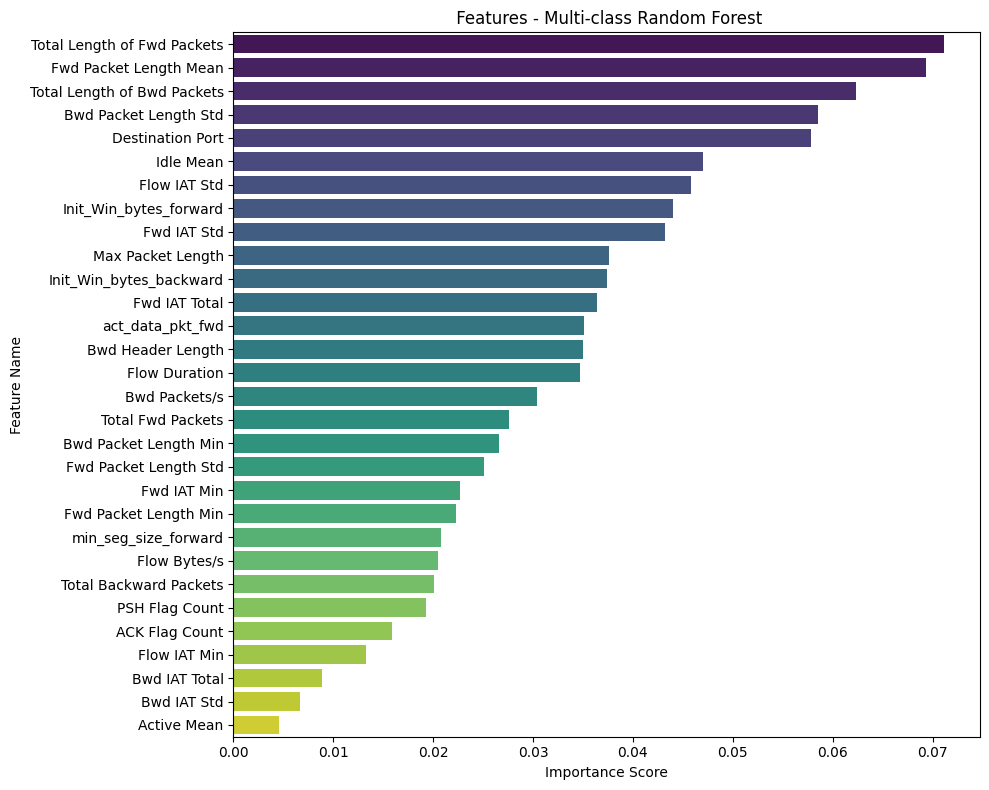

In [38]:
# Get importances from the trained multi-class model
final_importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_multi.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=final_importances, palette='viridis')
plt.title(' Features - Multi-class Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

# Next is to try other different models and make a comparaison between them

## 1. Binary classifiction models

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import gc

# 1. Initialize Models
models_bin = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, random_state=42, n_jobs=-1, tree_method='hist'),
    "KNN": KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
}

binary_results = []

# 2. Train and Evaluate
for name, model in models_bin.items():
    print(f"Training Binary {name}...")
    model.fit(X_train, y_train_bin)
    y_pred = model.predict(X_test)

    binary_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test_bin, y_pred),
        "Precision": precision_score(y_test_bin, y_pred),
        "Recall": recall_score(y_test_bin, y_pred),
        "F1-Score": f1_score(y_test_bin, y_pred),
        "Recall (Macro)": recall_score(y_test_bin, y_pred, average='macro', zero_division=0)
    })
    gc.collect()

# Add rf_binary to the comparison without re-training
print("Calculating metrics for pre-trained Random Forest (Binary)...")
binary_results.append({
    "Model": "Random Forest",
    "Accuracy": accuracy_score(y_test_bin, y_pred_bin),
    "Precision": precision_score(y_test_bin, y_pred_bin),
    "Recall": recall_score(y_test_bin, y_pred_bin),
    "F1-Score": f1_score(y_test_bin, y_pred_bin),
    "Recall (Macro)": recall_score(y_test_bin, y_pred_bin, average='macro', zero_division=0)
})

# 3. Display Comparison Table
df_bin_compare = pd.DataFrame(binary_results).sort_values(by="F1-Score", ascending=False)
print("\n=== Phase 7.3: Binary Model Comparison Table ===")
print(df_bin_compare.to_string(index=False))


Training Binary Logistic Regression...
Training Binary Decision Tree...
Training Binary XGBoost...
Training Binary KNN...
Calculating metrics for pre-trained Random Forest (Binary)...

=== Phase 7.3: Binary Model Comparison Table ===
              Model  Accuracy  Precision   Recall  F1-Score  Recall (Macro)
      Random Forest  0.998738   0.993207 0.999366  0.996277        0.998988
            XGBoost  0.998715   0.992562 0.999883  0.996209        0.999180
      Decision Tree  0.998346   0.991180 0.999096  0.995122        0.998644
                KNN  0.997062   0.983127 0.999765  0.991376        0.998139
Logistic Regression  0.889245   0.607064 0.975995  0.748540        0.923805


## 2. Multi-class models

In [40]:
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import recall_score, f1_score, accuracy_score

# XGBoost requires numeric labels for multi-class
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)

# 1. Initialize Models
models_multi = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, random_state=42, n_jobs=-1, tree_method='hist'),
    "KNN": KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
}

multi_results = []

# 2. Train and Evaluate
for name, model in models_multi.items():
    print(f"Training Multi-class {name}...")

    # Handle XGBoost specific encoding
    if name == "XGBoost":
        model.fit(X_train, y_train_enc)
        y_pred_raw = model.predict(X_test)
        y_pred = le.inverse_transform(y_pred_raw)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    multi_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Recall (Weighted)": recall_score(y_test, y_pred, average='weighted'),
        "F1-score (Weighted)": f1_score(y_test, y_pred, average='weighted'),
        "Recall (Macro)": recall_score(y_test, y_pred, average='macro', zero_division=0)
    })
    gc.collect()

# Add rf_multi to the comparison without re-training
print("Calculating metrics for pre-trained Random Forest (Multi-class)...")
# Ensure y_pred_multi from the RF model is used for its metrics
multi_results.append({
    "Model": "Random Forest",
    "Accuracy": accuracy_score(y_test, y_pred_multi),
    "Recall (Weighted)": recall_score(y_test, y_pred_multi, average='weighted'),
    "F1-score (Weighted)": f1_score(y_test, y_pred_multi, average='weighted'),
    "Recall (Macro)": recall_score(y_test, y_pred_multi, average='macro', zero_division=0)
})

# 3. Display Comparison Table
df_multi_compare = pd.DataFrame(multi_results).sort_values(by="Recall (Macro)", ascending=False)
print("\n=== Phase 8.3: Multi-class Model Comparison Table ===")
print(df_multi_compare.to_string(index=False))


Training Multi-class Logistic Regression...
Training Multi-class Decision Tree...
Training Multi-class XGBoost...
Training Multi-class KNN...
Calculating metrics for pre-trained Random Forest (Multi-class)...

=== Phase 8.3 & 9.5: Multi-class Model Comparison Table ===
              Model  Accuracy  Recall (Weighted)  F1-score (Weighted)  Recall (Macro)
                KNN  0.996640           0.996640             0.996965        0.910477
      Decision Tree  0.997761           0.997761             0.997853        0.909227
            XGBoost  0.998379           0.998379             0.998443        0.902282
      Random Forest  0.998417           0.998417             0.998457        0.894352
Logistic Regression  0.980900           0.980900             0.984809        0.848863


## Saving the models

In [43]:
import joblib
import os

# Define the base directory for saving baseline models
BASE_SAVE_PATH = '/content/drive/MyDrive/CNS/saved_models/'
BIN_PATH = os.path.join(BASE_SAVE_PATH, 'binary')
MULTI_PATH = os.path.join(BASE_SAVE_PATH, 'multi')

# Create folders if they don't exist
os.makedirs(BIN_PATH, exist_ok=True)
os.makedirs(MULTI_PATH, exist_ok=True)

print(f"Saving baseline models to {BASE_SAVE_PATH}...")

# 1. Save Binary Baseline Models
if 'models_bin' in locals():
    for name, model in models_bin.items():
        filename = f"{name.replace(' ', '_').lower()}_binary.joblib"
        joblib.dump(model, os.path.join(BIN_PATH, filename))
        print(f"  -> Saved: {filename}")

# 2. Save Multi-class Baseline Models
if 'models_multi' in locals():
    for name, model in models_multi.items():
        filename = f"{name.replace(' ', '_').lower()}_multi.joblib"
        joblib.dump(model, os.path.join(MULTI_PATH, filename))
        print(f"  -> Saved: {filename}")

# 3. Save initial Random Forest Baselines (from earlier cells)
if 'rf_binary' in locals():
    joblib.dump(rf_binary, os.path.join(BIN_PATH, 'random_forest_binary_baseline.joblib'))
    print("  -> Saved: random_forest_binary_baseline.joblib")

if 'rf_multi' in locals():
    joblib.dump(rf_multi, os.path.join(MULTI_PATH, 'random_forest_multi_baseline.joblib'))
    print("  -> Saved: random_forest_multi_baseline.joblib")

print("\nAll baseline models saved successfully!")

Saving baseline models to /content/drive/MyDrive/CNS/baseline_models/...
  -> Saved: logistic_regression_binary.joblib
  -> Saved: decision_tree_binary.joblib
  -> Saved: xgboost_binary.joblib
  -> Saved: knn_binary.joblib
  -> Saved: logistic_regression_multi.joblib
  -> Saved: decision_tree_multi.joblib
  -> Saved: xgboost_multi.joblib
  -> Saved: knn_multi.joblib
  -> Saved: random_forest_binary_baseline.joblib
  -> Saved: random_forest_multi_baseline.joblib

All baseline models saved successfully!


## Note :
- In specfic problems like this the most important evaluation metric to take into consideration is the Recall(more precisely the macro recall in the multi-class case) since it tells us of all the actual attacks that happened how many did the model catch?

- For Layer 1 (Binary):
  - Primary Metric: Recall. Because "Missing an attack is a disaster."

  - Stability Metric: Balanced Accuracy (Macro Recall). Because "We must also correctly identify normal traffic to avoid network downtime."

- For Layer 2 (Multi-class):
  - Primary Metric: Macro Recall. Because "Every one of the 14 attack types is a unique threat that must be identified, regardless of how many samples we have."

  - Pros of Macro recall :

    - Equal Importance: Macro Recall treats a rare Heartbleed attack (which could compromise your entire server) as just as important as a common DDoS attack.

    - No Hiding: A model cannot "hide" poor performance by simply being good at identifying the millions of BENIGN rows. If it misses the 11 Heartbleed samples, the Macro Recall will drop significantly.

    - Security Standard: For an IDS, "failing to catch a rare attack" is a critical failure. Macro Recall is the mathematical way to measure that failure.

## Best model according to the previously mentioned metrics
- Binary : ``XGBoost``
- Multi-class : ``KNN``

## Next?
Hyperparameters tuning could be done for the the model with the best results if we want to make the work more professional instead of relying on the default parameters
we can also perform cross validation to increase the robustness of the results.
  Finally we can save the models in an external folder to be used later on in the dashboard

## 8. Hyperparameter Tuning and Cross-Validation

We'll use `RandomizedSearchCV` to tune hyperparameters for the Random Forest models (both binary and multi-class) and incorporate cross-validation. This helps in finding better model configurations and ensuring the model's robustness.


### 8.1 Random Forest (Binary Classification) - Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
from scipy.stats import randint, uniform
import gc

print("\n--- Optimized Tuning for Binary XGBoost ---")

# Optimized Parameter Distribution
param_dist_xgb_binary = {
    'n_estimators': randint(100, 250),        # Slight increase, but histogram binning handles it fast
    'learning_rate': [0.01, 0.05, 0.1, 0.2], # Categorical choices often run faster than wide uniforms
    'max_depth': [3, 5, 7, 9],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'gamma': [0, 0.1, 0.2]
}

# Initialize XGBClassifier with 'hist' for massive speedup
# If using a GPU, change 'hist' to 'gpu_hist'
xgb_base_binary = XGBClassifier(
    objective='binary:logistic',
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss',
    tree_method='hist', # Fast histogram-based algorithm
    enable_categorical=True
)

# Initialize RandomizedSearchCV
# n_iter=10 is usually enough to find a great candidate significantly faster than 20
random_search_xgb_binary = RandomizedSearchCV(
    estimator=xgb_base_binary,
    param_distributions=param_dist_xgb_binary,
    n_iter=10,
    cv=3,
    verbose=1, # Reduced verbosity to keep log clean
    random_state=42,
    n_jobs=-1,
    scoring='f1'
)

# Fit to training data
random_search_xgb_binary.fit(X_train, y_train_bin)

print(f"\nBest parameters: {random_search_xgb_binary.best_params_}")
print(f"Best CV F1-score: {random_search_xgb_binary.best_score_:.4f}")

# Final Evaluation
best_xgb_binary_model = random_search_xgb_binary.best_estimator_
y_pred_tuned_bin = best_xgb_binary_model.predict(X_test)

print("\n=== Tuned Binary XGBoost Evaluation ===")
print(f"Accuracy: {accuracy_score(y_test_bin, y_pred_tuned_bin):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_bin, y_pred_tuned_bin, target_names=['BENIGN', 'ATTACK']))

gc.collect()


--- Optimized Tuning for Binary XGBoost ---
Fitting 3 folds for each of 10 candidates, totalling 30 fits


### 8.2 Random Forest (Multi-class Classification) - Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.neighbors import KNeighborsClassifier
from scipy.stats import randint
import gc

print("\n--- Tuning KNN for Multi-class Classification ---")

# Define parameter distributions for RandomizedSearchCV for KNN
param_dist_knn_multi = {
    'n_neighbors': randint(3, 15),          # Number of neighbors to use
    'weights': ['uniform', 'distance'],    # Weight function used in prediction
    'metric': ['euclidean', 'manhattan'],   # Distance metric
    'leaf_size': randint(20, 40)           # Leaf size passed to BallTree or KDTree
}

# Initialize KNeighborsClassifier
knn_base_multi = KNeighborsClassifier(n_jobs=-1)

# Initialize RandomizedSearchCV
# Using 'recall_macro' as the scoring metric per the user's requirement
random_search_knn_multi = RandomizedSearchCV(
    estimator=knn_base_multi,
    param_distributions=param_dist_knn_multi,
    n_iter=10, # KNN can be computationally expensive to tune on large datasets
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1,
    scoring='recall_macro'
)

# Fit RandomizedSearchCV to the training data
random_search_knn_multi.fit(X_train, y_train)

print("\nBest parameters for Multi-class KNN:", random_search_knn_multi.best_params_)
print("Best Macro Recall for Multi-class KNN:", random_search_knn_multi.best_score_)

# Get the best model
best_knn_multi_model = random_search_knn_multi.best_estimator_

# Evaluate the best model on the test set
y_pred_tuned_multi = best_knn_multi_model.predict(X_test)

print("\n=== Tuned Multi-class KNN Evaluation ===")
print(f"Overall Accuracy Score: {accuracy_score(y_test, y_pred_tuned_multi):.4f}")
print("\nClassification Report (Per-Class):")
print(classification_report(y_test, y_pred_tuned_multi, digits=4, zero_division=0))

gc.collect()

## Saving the tuned models

In [ ]:
import joblib
import os

# Reuse the same paths
BASE_SAVE_PATH = '/content/drive/MyDrive/CNS/saved_models/'
BIN_PATH = os.path.join(BASE_SAVE_PATH, 'binary')
MULTI_PATH = os.path.join(BASE_SAVE_PATH, 'multi')

print(f"Saving tuned models to {BASE_SAVE_PATH}...")

# 1. Save Tuned Binary Model (XGBoost)
if 'best_xgb_binary_model' in locals():
    filename = 'xgboost_binary_tuned.joblib'
    joblib.dump(best_xgb_binary_model, os.path.join(BIN_PATH, filename))
    print(f"  -> Saved Tuned Binary: {filename}")

# 2. Save Tuned Multi-class Model (KNN)
if 'best_knn_multi_model' in locals():
    filename = 'knn_multi_tuned.joblib'
    joblib.dump(best_knn_multi_model, os.path.join(MULTI_PATH, filename))
    print(f"  -> Saved Tuned Multi-class: {filename}")

print("\nRemaining tuned models saved successfully!")